In [ ]:
# Install Required Libraries

!pip install segmentation-models-pytorch
!pip install albumentations
!pip install opencv-python
!pip install torch torchvision
!pip install timm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 6.2 MB/s eta 0:00:00


In [ ]:
# Import Libraries

import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from glob import glob

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
from torchvision import transforms, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import albumentations as A

from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cpu


In [ ]:
# Mount Google Drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Check Drive Files

print(os.listdir("/content/drive/MyDrive/Biomass_Project"))

['biomass_data.zip', 'biomass_resnet50.pth']


In [ ]:
# Unzip Dataset

!unzip "/content/drive/MyDrive/Biomass_Project/biomass_data.zip" -d "/content/"

Archive:  /content/drive/MyDrive/Biomass_Project/biomass_data.zip
  inflating: /content/test/biomass_test_data.csv  
  inflating: /content/test/images/biomass_image_test_0000.jpg  
  inflating: /content/test/images/biomass_image_test_0001.jpg  
  inflating: /content/test/images/biomass_image_test_0002.jpg  
  inflating: /content/test/images/biomass_image_test_0003.jpg  
  inflating: /content/test/images/biomass_image_test_0004.jpg  
  inflating: /content/test/images/biomass_image_test_0005.jpg  
  inflating: /content/test/images/biomass_image_test_0006.jpg  
  inflating: /content/test/images/biomass_image_test_0007.jpg  
  inflating: /content/test/images/biomass_image_test_0008.jpg  
  inflating: /content/test/images/biomass_image_test_0009.jpg  
  inflating: /content/test/images/biomass_image_test_0010.jpg  
  inflating: /content/test/images/biomass_image_test_0011.jpg  
  inflating: /content/test/images/biomass_image_test_0012.jpg  
  inflating: /content/test/images/biomass_image_tes

In [ ]:
# Verify Dataset Structure

print(os.listdir("/content/test"))
print(os.listdir("/content/train"))


['biomass_test_data.csv', 'images']
['biomass_train_data.csv', 'images']


In [ ]:
# Load Train CSV

import pandas as pd

train_df = pd.read_csv(
    "/content/train/biomass_train_data.csv",
    sep=";"
)

train_df.head()

,image_file_name,acquisition_year,seasonal_harvest_no,label_type,fresh_grass,dry_grass,fresh_white_clover,dry_white_clover,fresh_red_clover,dry_red_clover,fresh_clover,dry_clover,fresh_weeds,dry_weeds,dry_total,dry_clover_fraction,dry_red_clover_fraction,dry_white_clover_fraction,dry_grass_fraction,dry_weeds_fraction
0,biomass_image_train_0000.jpg,2017,1,semi_advance,630.65,103.48,240.39,27.84,0.00,0.00,240.39,27.84,30.96,3.98,135.30,0.205765,0.000000,0.205765,0.764819,0.029416
1,biomass_image_train_0001.jpg,2017,1,basic,588.56,124.88,NaN,NaN,NaN,NaN,91.27,12.58,0.00,0.00,137.46,0.091518,0.000000,0.000000,0.908482,0.000000
2,biomass_image_train_0002.jpg,2017,1,semi_advance,437.74,83.06,3.91,0.64,0.00,0.00,3.91,0.64,27.38,3.44,87.14,0.007345,0.000000,0.007345,0.953179,0.039477
3,biomass_image_train_0003.jpg,2017,4,advance,72.39,9.92,221.12,26.86,8.98,1.51,230.10,28.37,80.44,9.76,48.05,0.590427,0.031426,0.559001,0.206452,0.203122
4,biomass_image_train_0004.jpg,2017,1,basic,111.21,23.14,NaN,NaN,NaN,NaN,417.18,61.11,0.00,0.00,84.25,0.725341,0.000000,0.000000,0.274659,0.000000


In [ ]:
TARGET_COLUMNS = [
    "fresh_grass",
    "dry_grass",
    "fresh_white_clover",
    "dry_white_clover",
    "fresh_red_clover",
    "dry_red_clover",
    "fresh_clover",
    "dry_clover",
    "fresh_weeds",
    "dry_weeds",
    "dry_total"
]


In [ ]:
print(train_df[TARGET_COLUMNS].isnull().sum())

fresh_grass             0
dry_grass               0
fresh_white_clover    104
dry_white_clover      104
fresh_red_clover      104
dry_red_clover        104
fresh_clover            0
dry_clover              0
fresh_weeds             0
dry_weeds               0
dry_total               0
dtype: int64


In [ ]:
# Load Test CSV

import pandas as pd

test_df = pd.read_csv(
    "/content/test/biomass_test_data.csv",
    sep=";"
)

test_df.head()

,image_file_name,acquisition_year,seasonal_harvest_no
0,biomass_image_test_0000.jpg,2017,2
1,biomass_image_test_0001.jpg,2017,2
2,biomass_image_test_0002.jpg,2017,3
3,biomass_image_test_0003.jpg,2017,3
4,biomass_image_test_0004.jpg,2017,4


In [ ]:
# Explore Dataset

print(train_df.shape)

print(test_df.shape)

(261, 20)
(174, 3)


In [ ]:
# Print Columns

print(train_df.columns)

Index(['image_file_name', 'acquisition_year', 'seasonal_harvest_no',
       'label_type', 'fresh_grass', 'dry_grass', 'fresh_white_clover',
       'dry_white_clover', 'fresh_red_clover', 'dry_red_clover',
       'fresh_clover', 'dry_clover', 'fresh_weeds', 'dry_weeds', 'dry_total',
       'dry_clover_fraction', 'dry_red_clover_fraction',
       'dry_white_clover_fraction', 'dry_grass_fraction',
       'dry_weeds_fraction'],
      dtype='object')


In [ ]:
#  Count Images

print("Training Images :", len(train_df))
print("Testing Images :", len(test_df))

Training Images : 261
Testing Images : 174


In [ ]:
train_df.isnull().sum()

,0
image_file_name,0
acquisition_year,0
seasonal_harvest_no,0
label_type,0
fresh_grass,0
dry_grass,0
fresh_white_clover,104
dry_white_clover,104
fresh_red_clover,104
dry_red_clover,104


In [ ]:
train_df[TARGET_COLUMNS].isnull().sum()

,0
fresh_grass,0
dry_grass,0
fresh_white_clover,104
dry_white_clover,104
fresh_red_clover,104
dry_red_clover,104
fresh_clover,0
dry_clover,0
fresh_weeds,0
dry_weeds,0


In [ ]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)

print("Training Images:", len(train_df))
print("Validation Images:", len(valid_df))

Training Images: 208
Validation Images: 53


In [ ]:
train_df[TARGET_COLUMNS] = train_df[TARGET_COLUMNS].fillna(0)
valid_df[TARGET_COLUMNS] = valid_df[TARGET_COLUMNS].fillna(0)

In [ ]:
print(train_df[TARGET_COLUMNS].isnull().sum())
print(valid_df[TARGET_COLUMNS].isnull().sum())

fresh_grass           0
dry_grass             0
fresh_white_clover    0
dry_white_clover      0
fresh_red_clover      0
dry_red_clover        0
fresh_clover          0
dry_clover            0
fresh_weeds           0
dry_weeds             0
dry_total             0
dtype: int64
fresh_grass           0
dry_grass             0
fresh_white_clover    0
dry_white_clover      0
fresh_red_clover      0
dry_red_clover        0
fresh_clover          0
dry_clover            0
fresh_weeds           0
dry_weeds             0
dry_total             0
dtype: int64


In [ ]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 208 entries, 0 to 207
Data columns (total 20 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   image_file_name            208 non-null    object 
 1   acquisition_year           208 non-null    int64  
 2   seasonal_harvest_no        208 non-null    int64  
 3   label_type                 208 non-null    object 
 4   fresh_grass                208 non-null    float64
 5   dry_grass                  208 non-null    float64
 6   fresh_white_clover         208 non-null    float64
 7   dry_white_clover           208 non-null    float64
 8   fresh_red_clover           208 non-null    float64
 9   dry_red_clover             208 non-null    float64
 10  fresh_clover               208 non-null    float64
 11  dry_clover                 208 non-null    float64
 12  fresh_weeds                208 non-null    float64
 13  dry_weeds                  208 non-null    float64

In [ ]:
train_df.describe()

,acquisition_year,seasonal_harvest_no,fresh_grass,dry_grass,fresh_white_clover,dry_white_clover,fresh_red_clover,dry_red_clover,fresh_clover,dry_clover,fresh_weeds,dry_weeds,dry_total,dry_clover_fraction,dry_red_clover_fraction,dry_white_clover_fraction,dry_grass_fraction,dry_weeds_fraction
count,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000,208.000000
mean,2017.081731,2.442308,187.347356,35.621346,70.986827,9.668413,36.005096,5.028221,176.647019,26.699231,23.130096,2.887788,65.208365,0.401157,0.067798,0.165105,0.550083,0.048760
std,0.274615,1.057085,145.079408,25.200619,99.286147,12.658571,105.954480,12.521230,172.627204,21.095839,38.877125,4.570896,32.569789,0.212714,0.127956,0.197734,0.223225,0.073843
min,2017.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.080000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2017.000000,2.000000,102.690000,18.725000,0.000000,0.000000,0.000000,0.000000,67.780000,12.852500,0.000000,0.000000,43.525000,0.246176,0.000000,0.000000,0.375386,0.000000
50%,2017.000000,2.000000,144.735000,28.350000,11.355000,2.040000,0.000000,0.000000,130.145000,23.435000,0.815000,0.260000,56.595000,0.388774,0.000000,0.055541,0.523525,0.005463
75%,2017.000000,3.000000,212.270000,44.797500,122.402500,16.662500,19.782500,3.582500,229.195000,35.770000,33.337500,4.792500,76.422500,0.542624,0.066658,0.329207,0.720750,0.074595
max,2018.000000,4.000000,848.030000,137.210000,442.960000,58.680000,855.460000,91.530000,1121.270000,144.400000,262.400000,36.270000,166.510000,1.000000,0.665286,0.655880,0.997526,0.361075


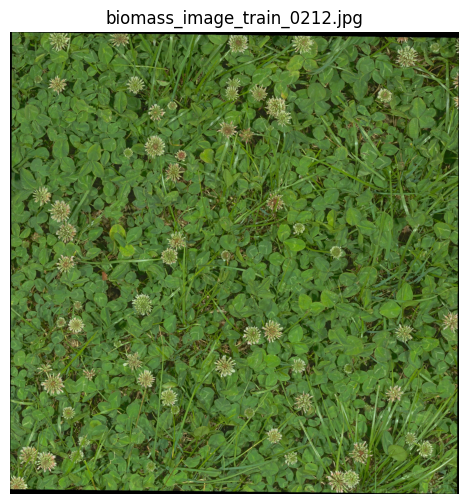

In [ ]:
# Display Images

import os
import cv2
import matplotlib.pyplot as plt

image_folder = "/content/train/images"

image_name = train_df.iloc[0]["image_file_name"]

image_path = os.path.join(image_folder, image_name)

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(6,6))
plt.imshow(image)
plt.title(image_name)
plt.axis("off")
plt.show()

In [ ]:
image = image / 255.0

print(image.min())
print(image.max())

0.0
1.0


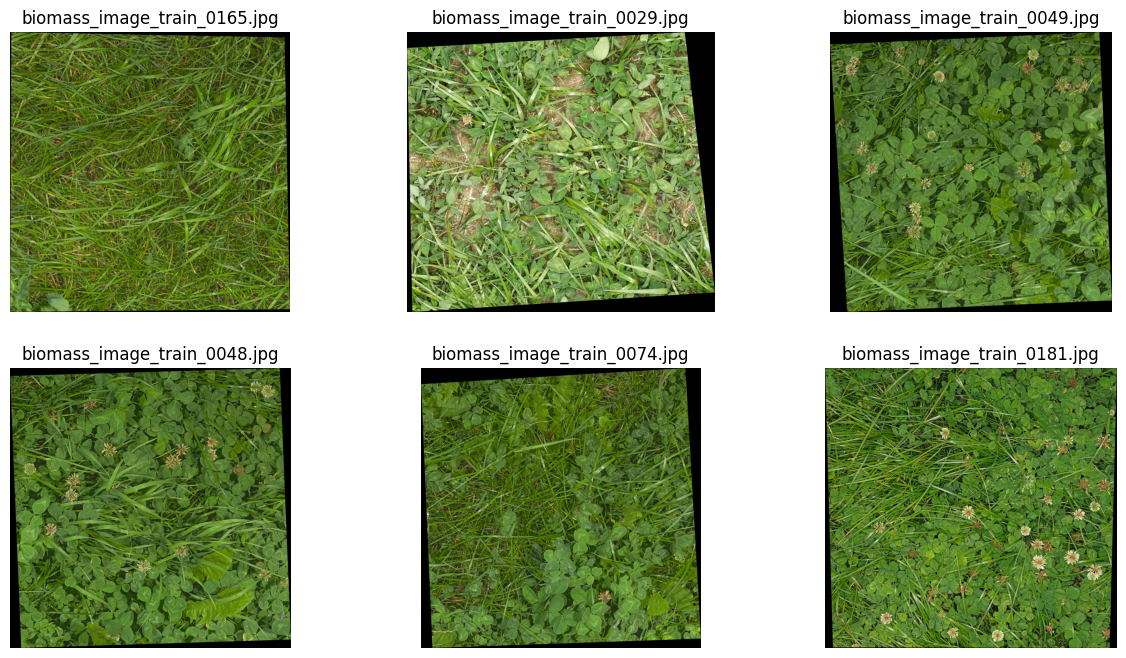

In [ ]:
# Display Multiple Images

import random

plt.figure(figsize=(15,8))

for i in range(6):

    plt.subplot(2,3,i+1)

    img_name = random.choice(train_df["image_file_name"])

    img = cv2.imread(os.path.join(image_folder, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")

plt.show()

In [ ]:
# Create Image Paths

import os

train_image_folder = "/content/train/images"
test_image_folder = "/content/test/images"

train_df["image_path"] = train_df["image_file_name"].apply(
    lambda x: os.path.join(train_image_folder, x)
)

test_df["image_path"] = test_df["image_file_name"].apply(
    lambda x: os.path.join(test_image_folder, x)
)

In [ ]:
# Verify Images

print(train_df["image_path"].iloc[0])

print(os.path.exists(train_df["image_path"].iloc[0]))

/content/train/images/biomass_image_train_0212.jpg
True


In [ ]:
# Define Target Columns

print("Number of Targets :", len(TARGET_COLUMNS))

Number of Targets : 11


In [ ]:
# Split the Training Data

from sklearn.model_selection import train_test_split

train_data, valid_data = train_test_split(
    train_df,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training Samples :", len(train_data))
print("Validation Samples :", len(valid_data))

Training Samples : 166
Validation Samples : 42


In [ ]:
# Image Transformations

from torchvision import transforms

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485,0.456,0.406],
        std=[0.229,0.224,0.225]
    )
])

In [54]:
# Import Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [65]:
# Missing Values Visualization

missing = train_df.isnull().sum()

missing = missing[missing > 0]

if len(missing) == 0:
    print("✅ No missing values found in the dataset.")
else:
    plt.figure(figsize=(10,6))
    missing.plot(kind="bar", color="red")
    plt.title("Missing Values in Dataset")
    plt.xlabel("Columns")
    plt.ylabel("Count")
    plt.xticks(rotation=90)
    plt.show()

✅ No missing values found in the dataset.


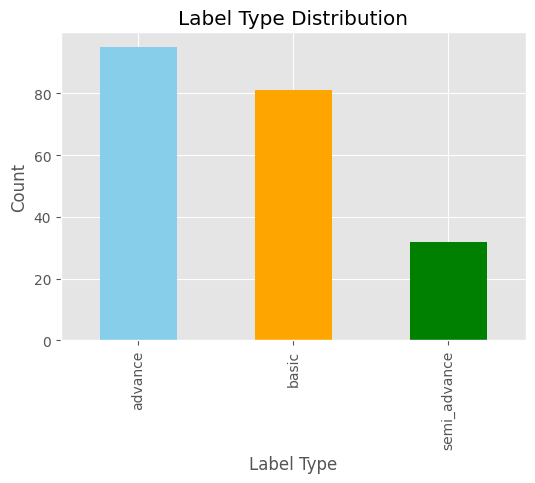

In [57]:
# Label Type Distribution

plt.figure(figsize=(6,4))

train_df["label_type"].value_counts().plot(
    kind="bar",
    color=["skyblue","orange","green"]
)

plt.title("Label Type Distribution")
plt.xlabel("Label Type")
plt.ylabel("Count")

plt.show()

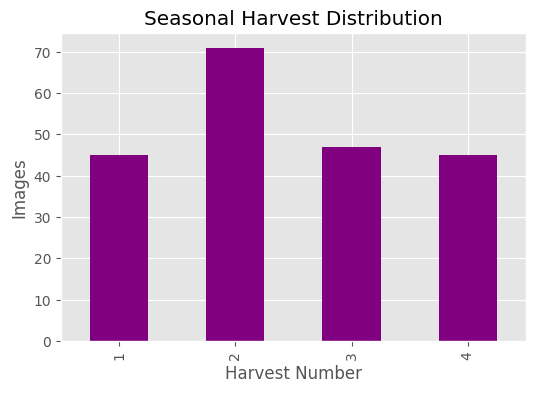

In [58]:
# Seasonal Harvest Distribution

plt.figure(figsize=(6,4))

train_df["seasonal_harvest_no"].value_counts().sort_index().plot(
    kind="bar",
    color="purple"
)

plt.title("Seasonal Harvest Distribution")
plt.xlabel("Harvest Number")
plt.ylabel("Images")

plt.show()

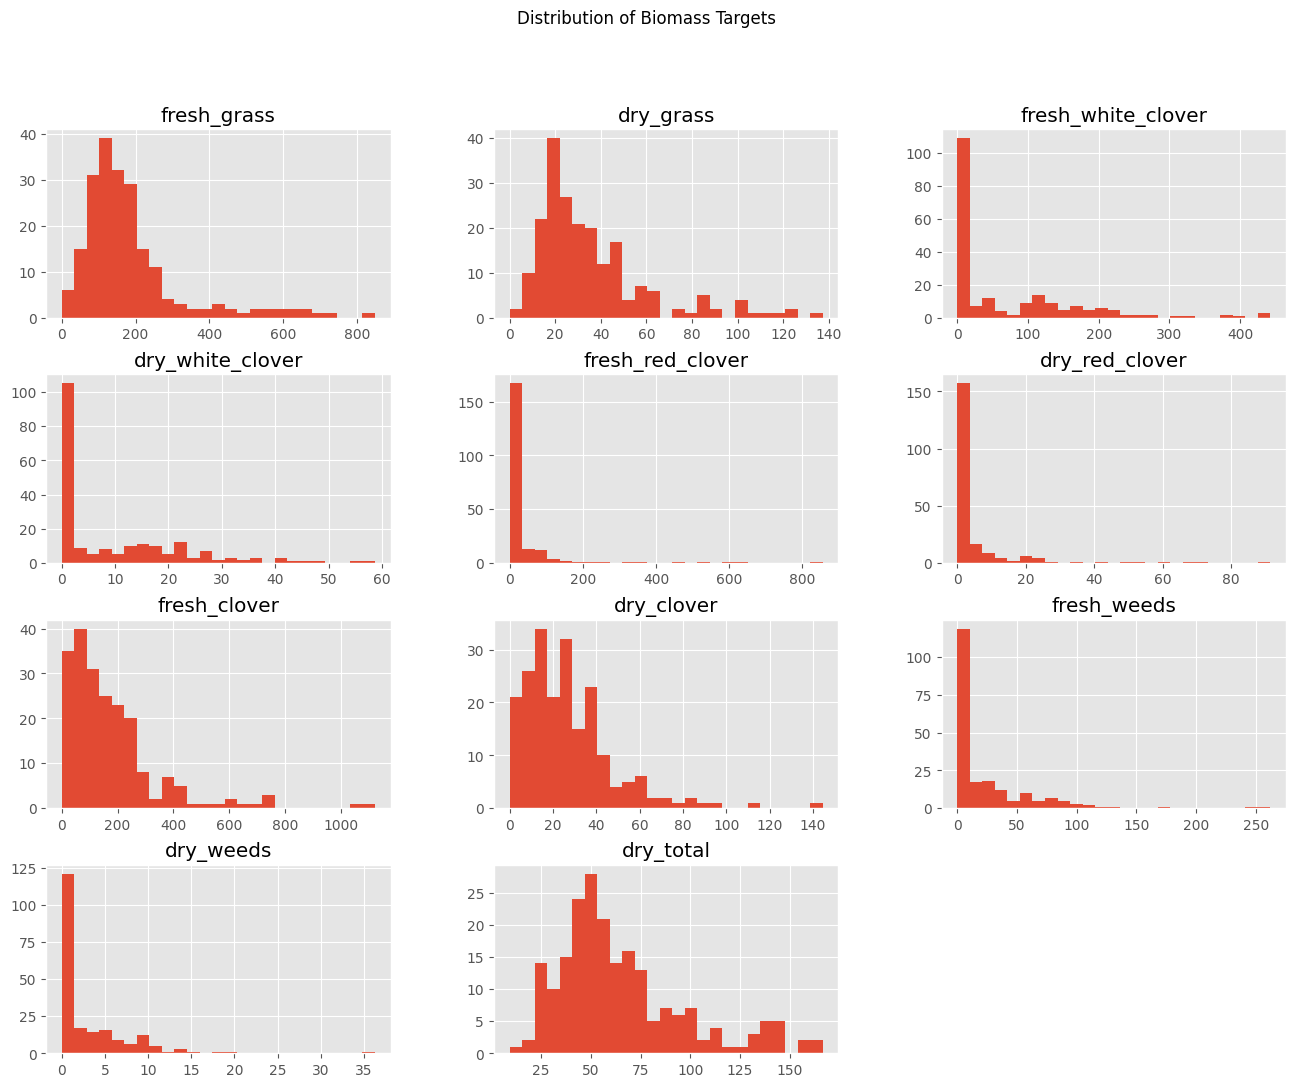

In [59]:
# Histogram of Target Variables

train_df[TARGET_COLUMNS].hist(
    figsize=(16,12),
    bins=25
)

plt.suptitle("Distribution of Biomass Targets")

plt.show()

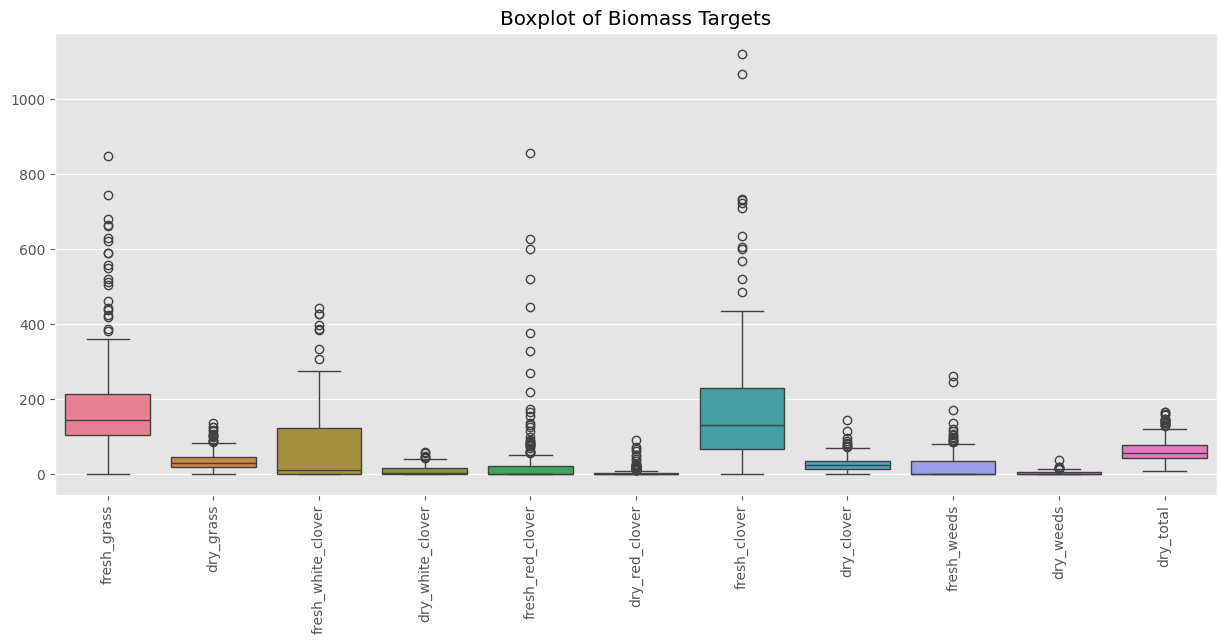

In [60]:
# Boxplots

plt.figure(figsize=(15,6))

sns.boxplot(data=train_df[TARGET_COLUMNS])

plt.xticks(rotation=90)

plt.title("Boxplot of Biomass Targets")

plt.show()

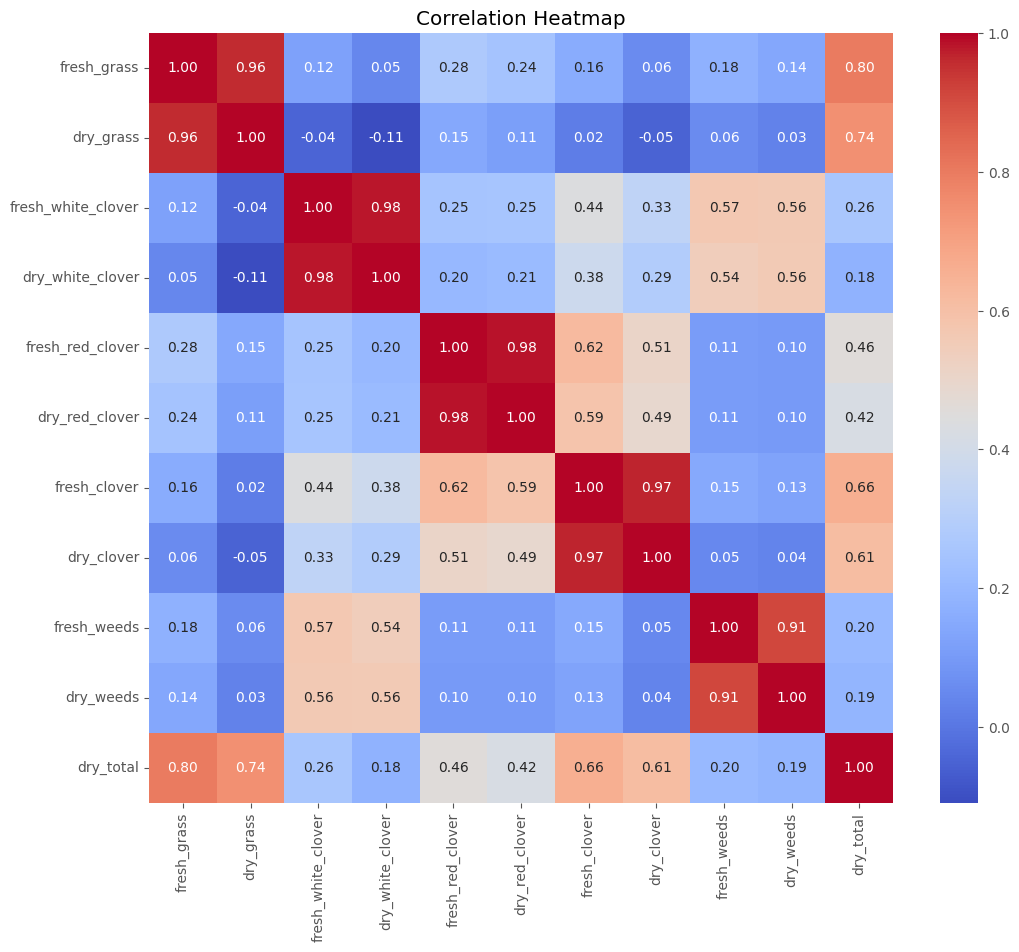

In [61]:
# Correlation Heatmap

plt.figure(figsize=(12,10))

corr = train_df[TARGET_COLUMNS].corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

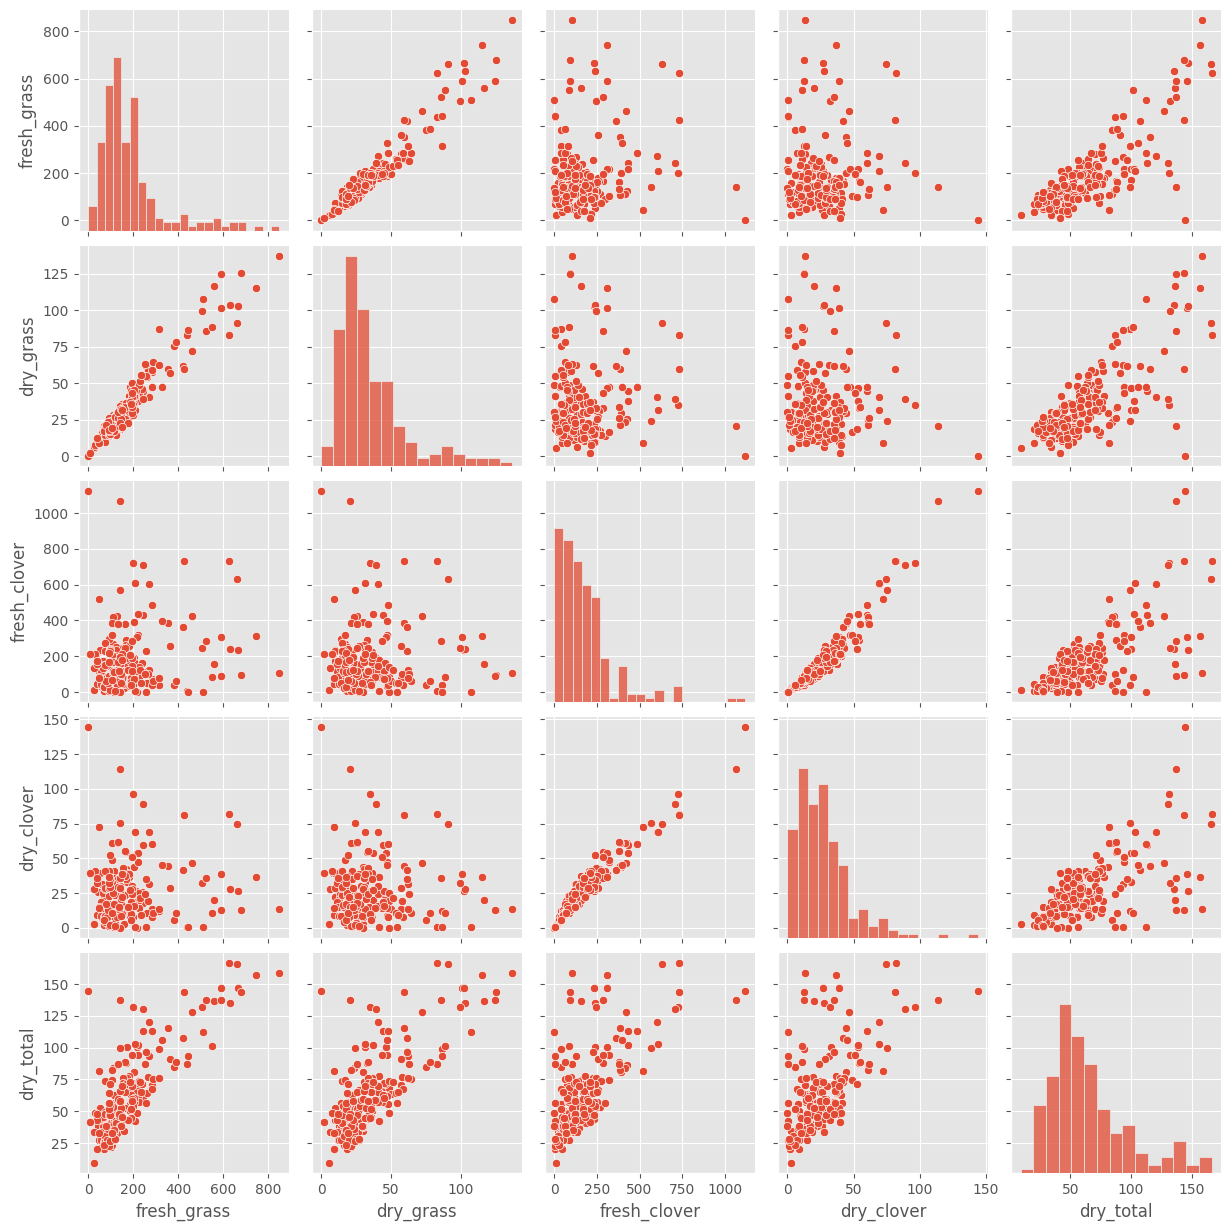

In [62]:
# Pairplot

sns.pairplot(
    train_df[
        [
            "fresh_grass",
            "dry_grass",
            "fresh_clover",
            "dry_clover",
            "dry_total"
        ]
    ]
)

plt.show()

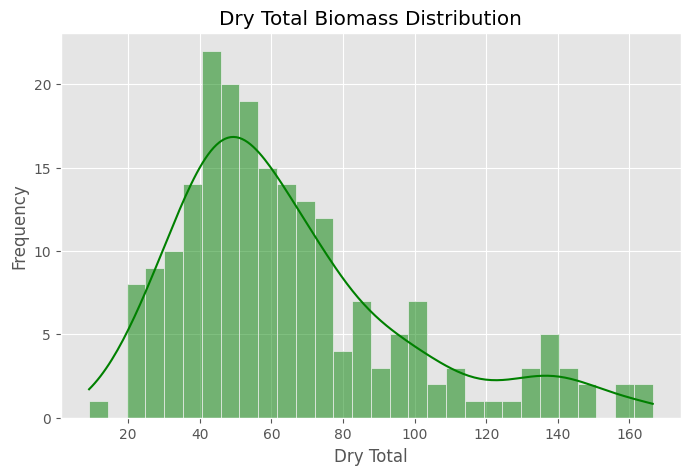

In [63]:
# Dry Total Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    train_df["dry_total"],
    bins=30,
    kde=True,
    color="green"
)

plt.title("Dry Total Biomass Distribution")

plt.xlabel("Dry Total")

plt.ylabel("Frequency")

plt.show()

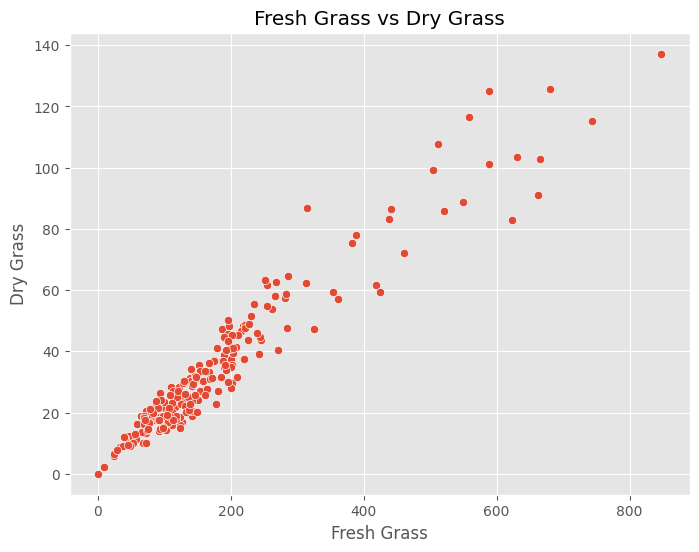

In [64]:
# Fresh Grass vs Dry Grass

plt.figure(figsize=(8,6))

sns.scatterplot(
    x=train_df["fresh_grass"],
    y=train_df["dry_grass"]
)

plt.title("Fresh Grass vs Dry Grass")

plt.xlabel("Fresh Grass")

plt.ylabel("Dry Grass")

plt.show()

In [ ]:
# Create Custom PyTorch Dataset

from torch.utils.data import Dataset
import cv2
import torch

class BiomassDataset(Dataset):

    def __init__(self, dataframe, transform=None):

        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, index):

        image_path = self.df.loc[index, "image_path"]

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        if self.transform:
            image = self.transform(image)

        target = self.df.loc[index, TARGET_COLUMNS].values.astype("float32")

        target = torch.tensor(target)

        return image, target

In [ ]:
train_dataset = BiomassDataset(train_data, transform=transform)
valid_dataset = BiomassDataset(valid_data, transform=transform)

In [ ]:
# Create Dataset Objects

train_dataset = BiomassDataset(
    train_data,
    transform=transform
)

valid_dataset = BiomassDataset(
    valid_data,
    transform=transform
)

print(len(train_dataset))
print(len(valid_dataset))

166
42


In [ ]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False
)

In [ ]:
# Create DataLoaders

from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=2
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=2
)

print("Train Loader Ready")
print("Validation Loader Ready")

Train Loader Ready
Validation Loader Ready


In [ ]:
images, labels = next(iter(train_loader))

print(torch.isnan(labels).sum())
print(labels.min())
print(labels.max())

tensor(0)
tensor(0.)
tensor(1121.2700)


In [ ]:
# Check One Batch

images, labels = next(iter(train_loader))

print(images.shape)
print(labels.shape)

torch.Size([16, 3, 224, 224])
torch.Size([16, 11])


In [ ]:
# Build the ResNet50 Model

import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

num_features = model.fc.in_features

model.fc = nn.Linear(num_features, len(TARGET_COLUMNS))

model = model.to(device)

print(model)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 175MB/s]


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Define Loss Function and Optimizer

criterion = nn.MSELoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.0001
)

In [ ]:
# Training Function

def train_one_epoch(model, loader):

    model.train()

    running_loss = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    return running_loss / len(loader)

In [ ]:
# Validation Function

def validate(model, loader):

    model.eval()

    running_loss = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

    return running_loss / len(loader)

In [ ]:
print(train_losses)
print(valid_losses)

[]
[]


In [ ]:
num_epochs = 5

train_losses = []
valid_losses = []

for epoch in range(num_epochs):

    # -------- Training --------
    model.train()
    running_train_loss = 0.0

    for images, targets in train_loader:

        images = images.to(device)
        targets = targets.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, targets)

        loss.backward()

        optimizer.step()

        running_train_loss += loss.item()

    epoch_train_loss = running_train_loss / len(train_loader)

    # -------- Validation --------
    model.eval()

    running_valid_loss = 0.0

    with torch.no_grad():

        for images, targets in valid_loader:

            images = images.to(device)
            targets = targets.to(device)

            outputs = model(images)

            loss = criterion(outputs, targets)

            running_valid_loss += loss.item()

    epoch_valid_loss = running_valid_loss / len(valid_loader)

    # Store losses
    train_losses.append(epoch_train_loss)
    valid_losses.append(epoch_valid_loss)

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Validation Loss: {epoch_valid_loss:.4f}")

Epoch 1/5 | Train Loss: 13893.0119 | Validation Loss: 12236.2194
Epoch 2/5 | Train Loss: 14637.1183 | Validation Loss: 11967.6771
Epoch 3/5 | Train Loss: 13653.6915 | Validation Loss: 10724.1022
Epoch 4/5 | Train Loss: 13068.9168 | Validation Loss: 9668.5410
Epoch 5/5 | Train Loss: 12400.7939 | Validation Loss: 9056.5667


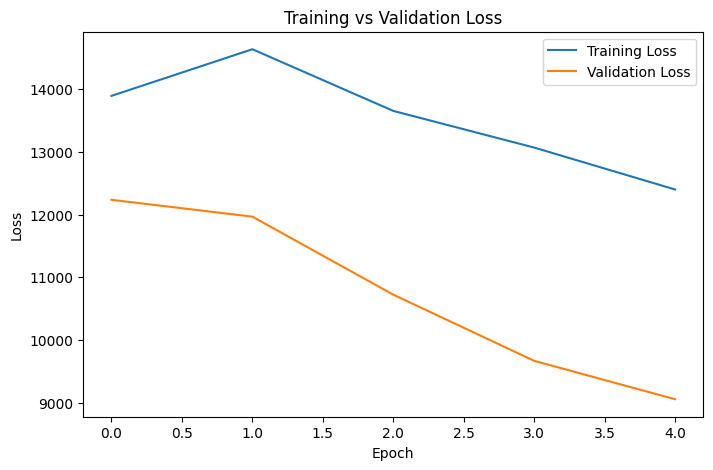

In [48]:
 # Plot Training Graph

plt.figure(figsize=(8,5))

plt.plot(train_losses, label="Training Loss")

plt.plot(valid_losses, label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.show()

In [49]:
# Save the Trained Model

torch.save(model.state_dict(), "biomass_resnet50.pth")

print("Model Saved Successfully")

Model Saved Successfully


In [50]:
# Load the Saved Model

model.load_state_dict(torch.load("biomass_resnet50.pth"))

model.eval()

print("Model Loaded")

Model Loaded


In [51]:
# Predict Biomass for One Image

sample_image, sample_label = valid_dataset[0]

sample_input = sample_image.unsqueeze(0).to(device)

prediction = model(sample_input)

prediction = prediction.cpu().detach().numpy()[0]

print("Predicted Biomass")

for name, value in zip(TARGET_COLUMNS, prediction):

    print(f"{name:25} : {value:.2f}")

Predicted Biomass
fresh_grass               : 0.33
dry_grass                 : 0.28
fresh_white_clover        : 0.33
dry_white_clover          : 0.21
fresh_red_clover          : 0.17
dry_red_clover            : 0.19
fresh_clover              : 0.31
dry_clover                : 0.37
fresh_weeds               : 0.22
dry_weeds                 : 0.06
dry_total                 : 0.33


In [52]:
torch.save(
    model.state_dict(),
    "/content/drive/MyDrive/Biomass_Project/biomass_resnet50.pth"
)

print("Saved to Google Drive")

Saved to Google Drive
